In [1]:
# Cricket Analytics
# Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("../data/cricket_data.xlsx")

print("Dataset Loaded Successfully")
print("Total Matches :", len(df))
print("Total Columns :", len(df.columns))

df.head()

Dataset Loaded Successfully
Total Matches : 1169
Total Columns : 23


,match_id,date_start,date_end,season,city,venue,match_type,gender,overs_limit,team_a,...,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,result_type,method,eliminator,player_of_match,player_of_match_id
0,335982,2008-04-18,2008-04-18,2007/08,Bangalore,M Chinnaswamy Stadium,T20,male,20,Royal Challengers Bangalore,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,NaN,normal,NaN,NaN,BB McCullum,b8a55852
1,335983,2008-04-19,2008-04-19,2007/08,Chandigarh,"Punjab Cricket Association Stadium, Mohali",T20,male,20,Kings XI Punjab,...,Chennai Super Kings,bat,Chennai Super Kings,33.0,NaN,normal,NaN,NaN,MEK Hussey,48fd7349
2,335984,2008-04-19,2008-04-19,2007/08,Delhi,Feroz Shah Kotla,T20,male,20,Delhi Daredevils,...,Rajasthan Royals,bat,Delhi Daredevils,NaN,9.0,normal,NaN,NaN,MF Maharoof,ab89348d
3,335985,2008-04-20,2008-04-20,2007/08,Mumbai,Wankhede Stadium,T20,male,20,Mumbai Indians,...,Mumbai Indians,bat,Royal Challengers Bangalore,NaN,5.0,normal,NaN,NaN,MV Boucher,f3cb53a1
4,335986,2008-04-20,2008-04-20,2007/08,Kolkata,Eden Gardens,T20,male,20,Kolkata Knight Riders,...,Deccan Chargers,bat,Kolkata Knight Riders,NaN,5.0,normal,NaN,NaN,DJ Hussey,fd835ab3


In [2]:
# Dataset Overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(1169, 23)

Column Names:
['match_id', 'date_start', 'date_end', 'season', 'city', 'venue', 'match_type', 'gender', 'overs_limit', 'team_a', 'team_b', 'event_name', 'event_stage', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'result_type', 'method', 'eliminator', 'player_of_match', 'player_of_match_id']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   match_id            1169 non-null   int64         
 1   date_start          1169 non-null   datetime64[us]
 2   date_end            1169 non-null   datetime64[us]
 3   season              1169 non-null   str           
 4   city                1118 non-null   str           
 5   venue               1169 non-null   str           
 6   match_type          1169 non-null   str           
 7   gender              116

In [3]:
# Missing Values Analysis

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values[missing_values > 0])

print("\nTotal Missing Values:")
print(missing_values.sum())

Missing Values in Each Column:
city                    51
event_stage           1099
winner                  23
win_by_runs            638
win_by_wickets         554
method                1147
eliminator            1154
player_of_match          8
player_of_match_id       8
dtype: int64

Total Missing Values:
4682


In [4]:
# Duplicate Records Analysis

duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

if duplicate_count == 0:
    print("✅ No duplicate records found.")
else:
    print("⚠️ Duplicate records found.")

Total Duplicate Records: 0
✅ No duplicate records found.


In [5]:
# Team Performance Analysis

team_wins = df["winner"].value_counts()

print("Top 10 Winning Teams:")
print(team_wins.head(10))

Top 10 Winning Teams:
winner
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    114
Rajasthan Royals               114
Sunrisers Hyderabad             93
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  51
Gujarat Titans                  37
Name: count, dtype: int64


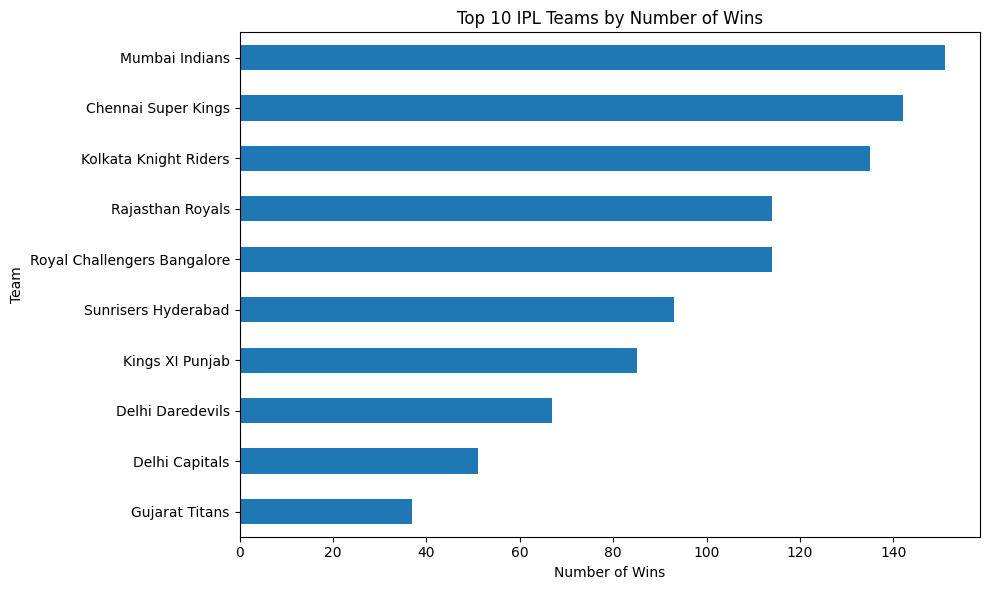

In [6]:
# Team Wins Visualization

top_teams = team_wins.head(10)

plt.figure(figsize=(10, 6))
top_teams.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Teams by Number of Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

In [7]:
# Player of the Match Analysis

player_awards = df["player_of_match"].value_counts()

print("Top 10 Players by Player of the Match Awards:")
print(player_awards.head(10))

Top 10 Players by Player of the Match Awards:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
MS Dhoni          18
DA Warner         18
SP Narine         17
SR Watson         16
YK Pathan         16
RA Jadeja         16
Name: count, dtype: int64


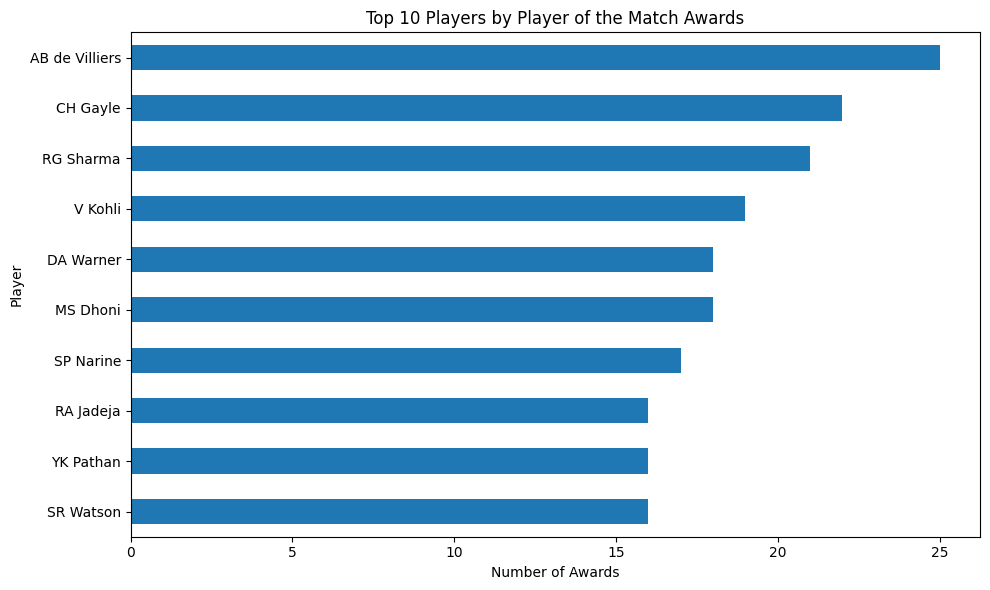

In [8]:
# Top Players Visualization

top_players = player_awards.head(10)

plt.figure(figsize=(10, 6))
top_players.sort_values().plot(kind="barh")

plt.title("Top 10 Players by Player of the Match Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [9]:
# Matches by Season

matches_by_season = df["season"].value_counts().sort_index()

print("Matches Played by Season:")
print(matches_by_season)

Matches Played by Season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
Name: count, dtype: int64


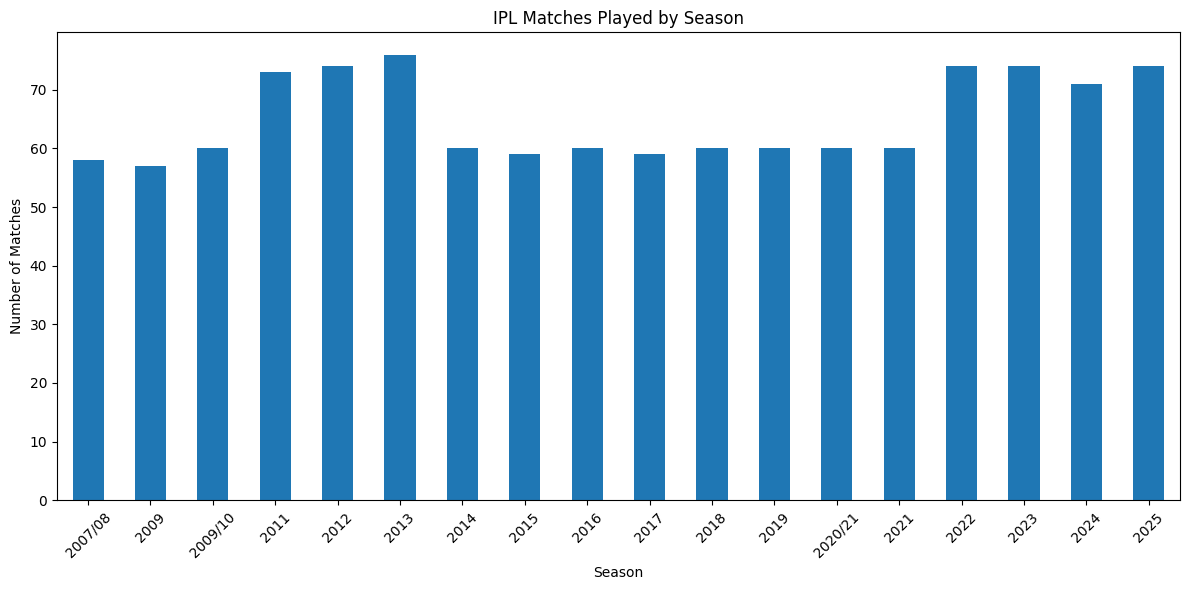

In [10]:
# Matches by Season Visualization

plt.figure(figsize=(12, 6))
matches_by_season.plot(kind="bar")

plt.title("IPL Matches Played by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Toss Decision Analysis

toss_decisions = df["toss_decision"].value_counts()

print("Toss Decisions:")
print(toss_decisions)

print("\nToss Decision Percentages:")
print((toss_decisions / toss_decisions.sum() * 100).round(2))

Toss Decisions:
toss_decision
field    764
bat      405
Name: count, dtype: int64

Toss Decision Percentages:
toss_decision
field    65.36
bat      34.64
Name: count, dtype: float64


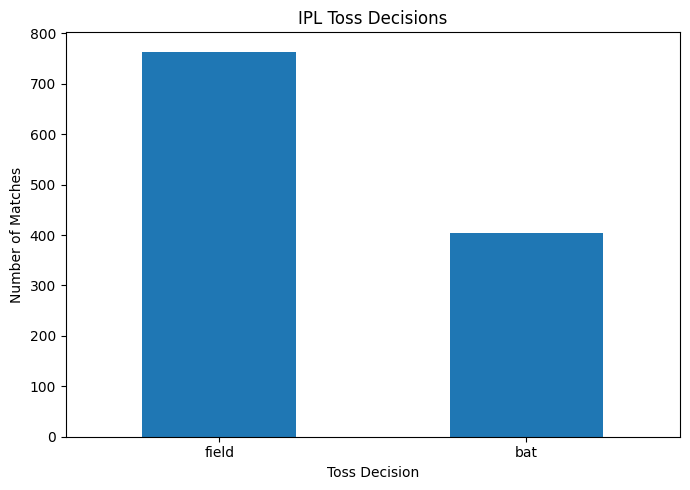

In [12]:
# Toss Decision Visualization

plt.figure(figsize=(7, 5))
toss_decisions.plot(kind="bar")

plt.title("IPL Toss Decisions")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Win by Runs Analysis

runs_data = df["win_by_runs"].dropna()

print("Win by Runs Statistics:")
print(runs_data.describe())

print("\nAverage Win by Runs:", round(runs_data.mean(), 2))
print("Maximum Win by Runs:", int(runs_data.max()))

Win by Runs Statistics:
count    531.000000
mean      30.295669
std       26.866707
min        1.000000
25%       11.000000
50%       22.000000
75%       41.000000
max      146.000000
Name: win_by_runs, dtype: float64

Average Win by Runs: 30.3
Maximum Win by Runs: 146


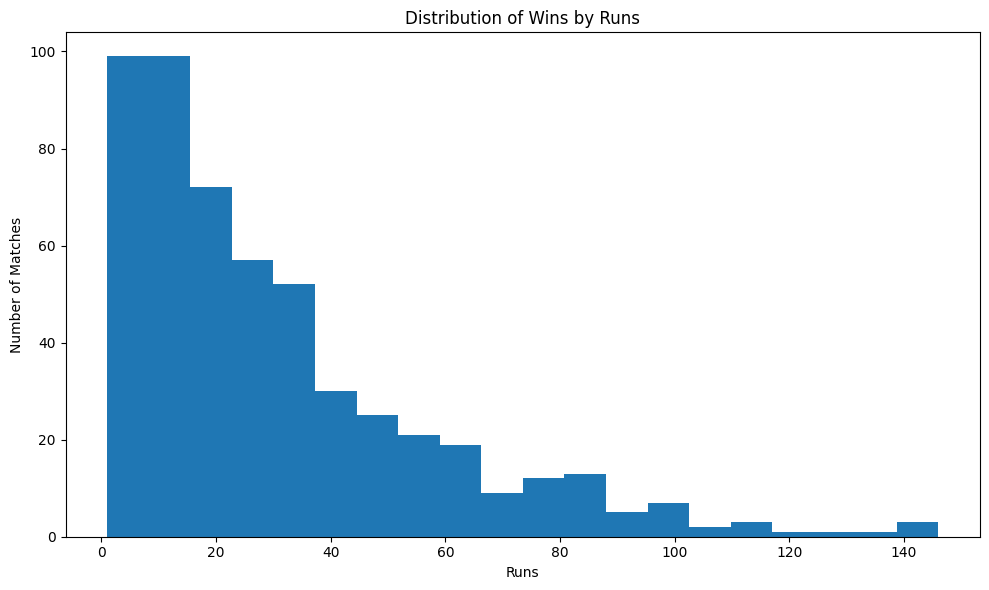

In [14]:
# Win by Runs Visualization

plt.figure(figsize=(10, 6))
plt.hist(runs_data, bins=20)

plt.title("Distribution of Wins by Runs")
plt.xlabel("Runs")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

In [15]:
# Win by Wickets Analysis

wickets_data = df["win_by_wickets"].dropna()

print("Win by Wickets Statistics:")
print(wickets_data.describe())

print("\nAverage Win by Wickets:", round(wickets_data.mean(), 2))
print("Maximum Win by Wickets:", int(wickets_data.max()))

Win by Wickets Statistics:
count    615.000000
mean       6.200000
std        1.852193
min        1.000000
25%        5.000000
50%        6.000000
75%        7.500000
max       10.000000
Name: win_by_wickets, dtype: float64

Average Win by Wickets: 6.2
Maximum Win by Wickets: 10


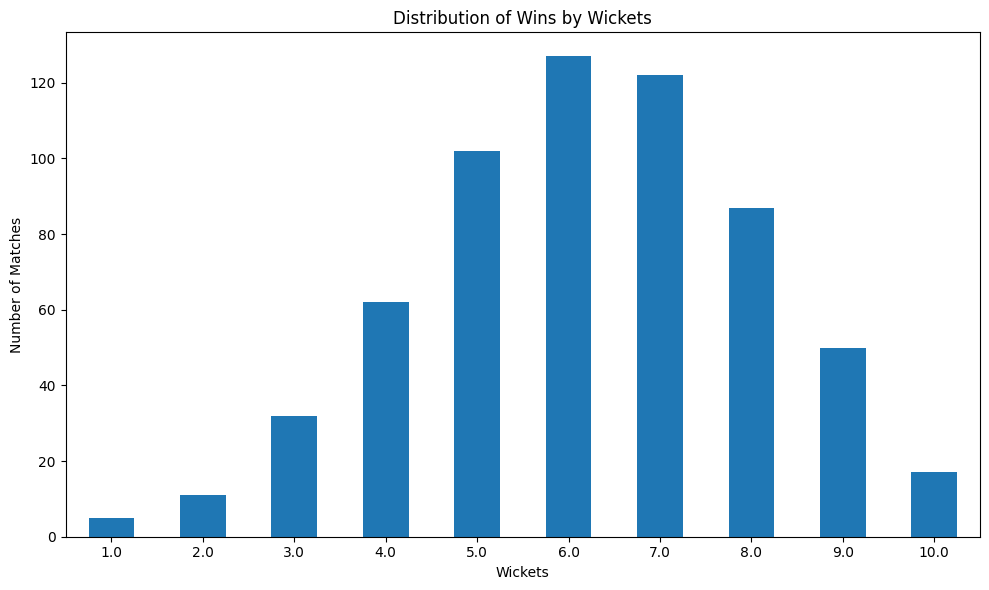

In [16]:
# Win by Wickets Visualization

plt.figure(figsize=(10, 6))
wickets_data.value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Wins by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Top Venues Analysis

top_venues = df["venue"].value_counts().head(10)

print("Top 10 Venues by Number of Matches:")
print(top_venues)

Top 10 Venues by Number of Matches:
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Wankhede Stadium, Mumbai                      52
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


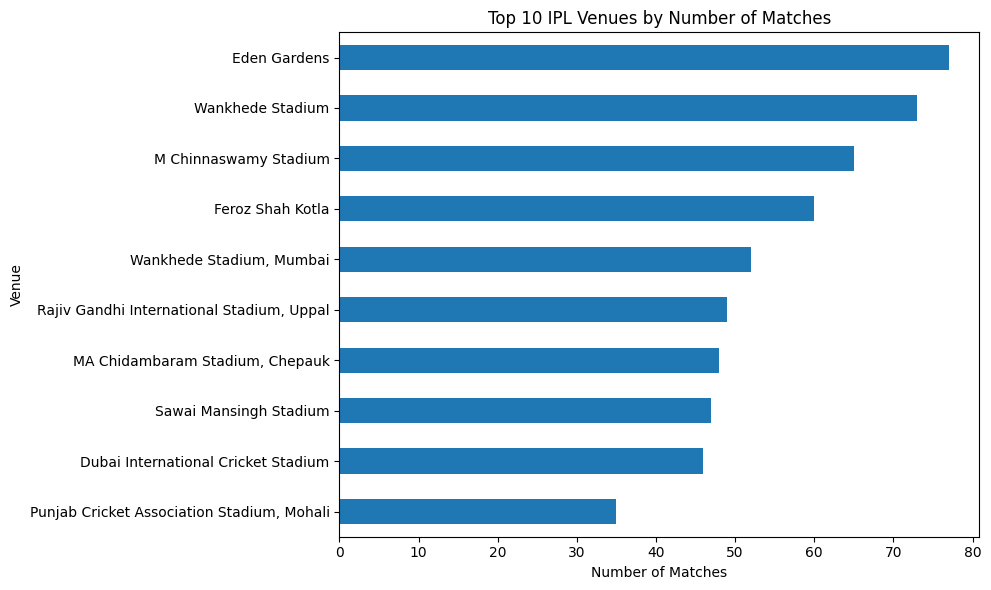

In [18]:
# Top Venues Visualization

plt.figure(figsize=(10, 6))
top_venues.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

## Key Insights

- **Mumbai Indians** have the highest number of wins in the dataset.
- **AB de Villiers** has the highest number of Player of the Match awards.
- Teams chose to **field first more often than bat first** after winning the toss.
- The average winning margin for matches won by runs is approximately **30 runs**.
- The average winning margin for matches won by wickets is approximately **6 wickets**.
- **Eden Gardens** is among the venues with the highest number of matches.
- The dataset contains **1,169 IPL matches** across multiple seasons.